In [ ]:
# =======================================================
# Installations, Imports, and Connection
# =======================================================

# 1. Install required libraries
print("Installing required libraries...")
!pip install ultralytics torch torchvision opencv-python-headless pandas scikit-learn seaborn timm -q
print("Installations complete.")

# 2. Import all necessary libraries for the project
import os
import shutil
import cv2
import numpy as np
import pandas as pd
from ultralytics import YOLO
from PIL import Image
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import timm

# 3. Connect Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive connected successfully.")
except ImportError:
    print("Not in Colab environment, skipping Drive connection.")

print("\nAll set, you can proceed to the next cell.")

In [ ]:
# =======================================================
# Script to add all new images to the training set only
# =======================================================

import os
import cv2
from ultralytics import YOLO
import torch

# --- 1. Define Paths ---
YOLO_MODEL_PATH = '/content/drive/MyDrive/yolov11_atk_train/output/atk_yolov11/weights/best.pt'
DESTINATION_BASE_DIR = '/content/drive/MyDrive/Covid_Classification_Dataset'

# images taken from this folder (temporary)
RAW_IMAGES_SOURCE_DIR = '/content/drive/MyDrive/new_55_for_train_only'
# -----------------------------------------------------------

def crop_and_place_in_train_only(yolo_path, source_dir, dest_dir):
    model = YOLO(yolo_path)
    print("YOLO model loaded successfully.")

    if not os.path.exists(source_dir):
        print(f"ERROR: Source directory not found: {source_dir}")
        return

    image_files = [f for f in os.listdir(source_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Found {len(image_files)} new images. Adding all of them to the 'train' set.")
    processed_count = 0

    for filename in image_files:
        target_category = 'INVALID'
        if 'pos' in filename.lower(): target_category = 'POSITIVE'
        elif 'neg' in filename.lower(): target_category = 'NEGATIVE'

        final_dest_folder = os.path.join(dest_dir, 'train', target_category)
        os.makedirs(final_dest_folder, exist_ok=True)
        output_path = os.path.join(final_dest_folder, f"cropped_{filename}")

        if os.path.exists(output_path): continue

        image_path = os.path.join(source_dir, filename)
        try:
            results = model(image_path, verbose=False)
            if results and results[0].boxes:
                box = results[0].boxes[0]; xyxy = box.xyxy[0].cpu().numpy().astype(int)
                x1, y1, x2, y2 = xyxy; original_image = cv2.imread(image_path)
                cropped_image = original_image[y1:y2, x1:x2]
                cv2.imwrite(output_path, cropped_image)
                processed_count += 1
        except Exception as e:
            print(f"Error processing file '{filename}': {e}")

    print(f"\nDirect cropping process finished. {processed_count} new images were added to the train set.")

# --- Run the function ---
crop_and_place_in_train_only(YOLO_MODEL_PATH, RAW_IMAGES_SOURCE_DIR, DESTINATION_BASE_DIR)

YOLO model loaded successfully.
Found 48 new images. Adding all of them to the 'train' set.

Direct cropping process finished. 48 new images were added to the train set.


#It should be noted that in the first run of the program I loaded all the images of the set, about 900 images,
After I wanted to achieve higher accuracy I added more images to the image database
Therefore in the second run the output of the 48 images was saved

In [5]:
# =======================================================
# Helper functions for the classification model
# =======================================================

def load_classification_dataset(data_dir, batch_size=32):
    """
    Loads the cropped image dataset
    """
    train_transform = transforms.Compose([
        transforms.Resize((192, 192)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((192, 192)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_dataset = ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
    val_dataset = ImageFolder(os.path.join(data_dir, "val"), transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    print(f"Data loaded successfully. Classes found: {train_dataset.classes}")
    return train_loader, val_loader, train_dataset.classes

def initialize_swin_transformer_model(num_classes, model_name='swinv2_base_window12_192.ms_in22k'):
    """
    Initializes the Swin Transformer V2 model
    """
    model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

    print(f"Model '{model_name}' initialized for {num_classes} classes.")
    return model


def train_classifier(model, train_loader, val_loader, num_epochs, learning_rate):
    """
    General training function for the classification model.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on device: {device}")
    model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    best_accuracy = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = 100 * correct / total

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Val Accuracy: {epoch_acc:.2f}%")

        if epoch_acc > best_accuracy:
            best_accuracy = epoch_acc
            torch.save(model.state_dict(), '/content/drive/MyDrive/covid_classifier_swin_best.pt') # Saving with a new name
            print(f"  -> New best model saved with accuracy: {best_accuracy:.2f}%")

    print("\nFinished Training.")
    return model

print("Helper functions defined")

Helper functions defined


In [ ]:
# =======================================================
#                 Training the New Model
# =======================================================

# --- Define Dataset Path ---
CLASSIFICATION_DATASET_DIR = '/content/drive/MyDrive/Covid_Classification_Dataset'
print(f"Dataset path for training set to: {CLASSIFICATION_DATASET_DIR}")

# 1. Load your clean and sorted dataset
train_loader, val_loader, class_names = load_classification_dataset(CLASSIFICATION_DATASET_DIR)
NUM_CLASSES = len(class_names)

# --- Call the new model initialization function ---
classifier_model = initialize_swin_transformer_model(num_classes=NUM_CLASSES)

# 3. Train the model
# Large models sometimes require a lower learning rate and fewer iterations
print("\nStarting model training...")
trained_classifier = train_classifier(classifier_model, train_loader, val_loader, num_epochs=15, learning_rate=0.00005)

print("\nModel training finished. The best model is saved in Drive.")

Dataset path for training set to: /content/drive/MyDrive/Covid_Classification_Dataset
Data loaded successfully. Classes found: ['INVALID', 'NEGATIVE', 'POSITIVE']


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

Model 'swinv2_base_window12_192.ms_in22k' initialized for 3 classes.

Starting model training...
Training on device: cuda
Epoch 1/15 | Train Loss: 0.9206 | Val Accuracy: 85.93%
  -> New best model saved with accuracy: 85.93%
Epoch 2/15 | Train Loss: 0.3532 | Val Accuracy: 92.02%
  -> New best model saved with accuracy: 92.02%
Epoch 3/15 | Train Loss: 0.1666 | Val Accuracy: 96.58%
  -> New best model saved with accuracy: 96.58%
Epoch 4/15 | Train Loss: 0.2249 | Val Accuracy: 82.89%
Epoch 5/15 | Train Loss: 0.2114 | Val Accuracy: 95.82%
Epoch 6/15 | Train Loss: 0.1165 | Val Accuracy: 97.34%
  -> New best model saved with accuracy: 97.34%
Epoch 7/15 | Train Loss: 0.0735 | Val Accuracy: 96.96%
Epoch 8/15 | Train Loss: 0.0330 | Val Accuracy: 96.58%
Epoch 9/15 | Train Loss: 0.0522 | Val Accuracy: 96.96%
Epoch 10/15 | Train Loss: 0.0724 | Val Accuracy: 91.63%
Epoch 11/15 | Train Loss: 0.1012 | Val Accuracy: 95.06%
Epoch 12/15 | Train Loss: 0.0740 | Val Accuracy: 97.72%
  -> New best model sav

טוען את המודל המאומן...
Model 'swinv2_base_window12_192.ms_in22k' initialized for 3 classes.
המודל מוכן לשימוש.

--- מתחיל הערכה מקיפה על כל סט האימות ---

--- Evaluation Summary ---
המודל הצליח לזהות נכונה 156 תמונות מתוך סך של 161 תמונות שנבדקו.
** Final Model Accuracy: 96.89% **

--- Classification Report ---
              precision    recall  f1-score   support

     INVALID       0.71      1.00      0.83        10
    NEGATIVE       1.00      0.92      0.96        49
    POSITIVE       0.99      0.99      0.99       102

    accuracy                           0.97       161
   macro avg       0.90      0.97      0.93       161
weighted avg       0.98      0.97      0.97       161


--- Confusion Matrix ---


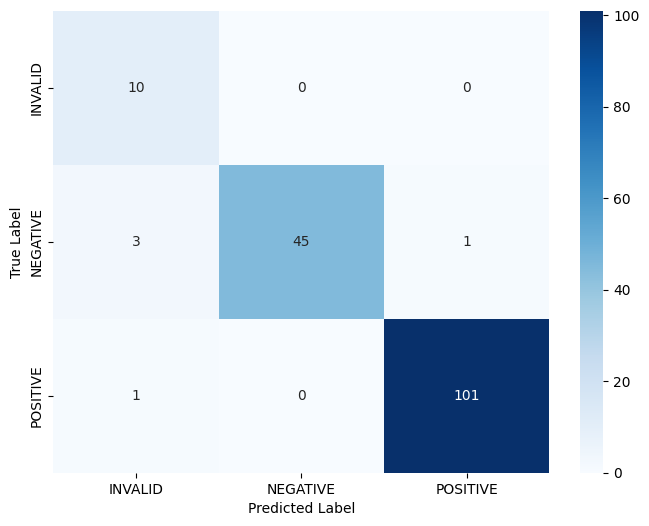



--- הדגמה ויזואלית של תוצאות נבחרות ---

--- 2 דוגמאות לזיהוי נכון של 'NEGATIVE' ---


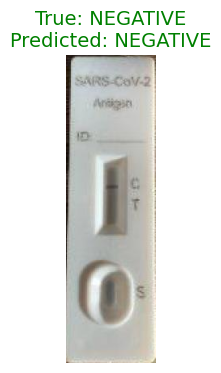

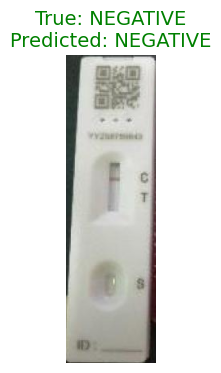



--- 2 דוגמאות לזיהוי נכון של 'POSITIVE' ---


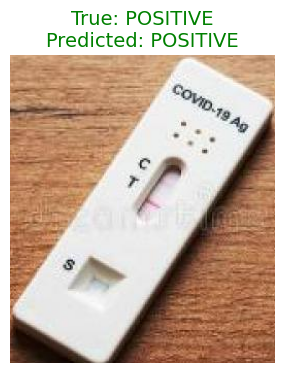

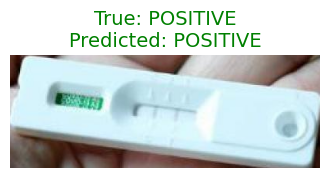



--- דוגמה לזיהוי שגוי של המודל ---


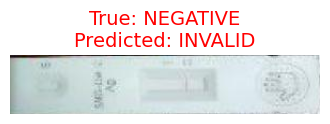

In [ ]:
# =======================================================
#  Evaluation with Visual Demonstration of Cropped Images
# =======================================================

# --- Import required evaluation libraries ---
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import random

# --- Define Paths ---
YOLO_MODEL_PATH = '/content/drive/MyDrive/yolov11_atk_train/output/atk_yolov11/weights/best.pt'
ORIGINAL_YOLO_DATASET_DIR = '/content/drive/MyDrive/yolov11_atk_train/dataset'
CLASSIFICATION_DATASET_DIR = '/content/drive/MyDrive/Covid_Classification_Dataset'

# --- Load the best trained model ---
print("Loading the trained model...")
try:
    class_names = sorted([d.name for d in os.scandir(os.path.join(CLASSIFICATION_DATASET_DIR, "train")) if d.is_dir()])
    # Make sure this function is defined in cell 3
    final_model = initialize_swin_transformer_model(num_classes=len(class_names))
    model_save_path = '/content/drive/MyDrive/covid_classifier_swin_best.pt'
    final_model.load_state_dict(torch.load(model_save_path))
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    final_model.to(device)
    final_model.eval()
    print("Model is ready for use.")
except Exception as e:
    print(f"Error loading the model: {e}")

# --- Single diagnosis function (updated to also return the cropped image) ---
def diagnose_covid_test(raw_image_path, yolo_model, classifier_model, class_names):
    """Receives a raw image, detects, crops, classifies, and returns the prediction and the cropped image."""
    try:
        results = yolo_model(raw_image_path, verbose=False)
        if not results[0].boxes: return "NO_DETECTION", None
        original_image = cv2.imread(raw_image_path)
        box = results[0].boxes[0]; xyxy = box.xyxy[0].cpu().numpy().astype(int)
        x1, y1, x2, y2 = xyxy; cropped_image = original_image[y1:y2, x1:x2]

        # Convert the cropped image to a format suitable for the classification model
        cropped_pil_image_for_model = Image.fromarray(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))
        val_transform = transforms.Compose([
            transforms.Resize((192, 192)), transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        image_tensor = val_transform(cropped_pil_image_for_model).unsqueeze(0).to(device)

        with torch.no_grad():
            output = classifier_model(image_tensor)
            _, predicted_idx = torch.max(output.data, 1)
        prediction = class_names[predicted_idx.item()]

        # Return the prediction, and also the cropped image for display
        return prediction, cropped_pil_image_for_model
    except Exception as e:
        return f"Error: {e}", None

# --- Upgraded evaluation function ---
def scientific_evaluation(base_folder_path, yolo_model, classifier_model, class_names):
    print(f"\n--- Starting comprehensive evaluation on the entire validation set ---")
    validation_images_dir = os.path.join(base_folder_path, 'valid', 'images')
    image_files = [f for f in os.listdir(validation_images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    y_true, y_pred, correct_results_list, incorrect_results_list = [], [], [], []
    for image_file in image_files:
        true_label = None
        if 'pos' in image_file.lower(): true_label = 'POSITIVE'
        elif 'neg' in image_file.lower(): true_label = 'NEGATIVE'
        elif 'invalid' in image_file.lower(): true_label = 'INVALID'
        if not true_label: continue
        full_path = os.path.join(validation_images_dir, image_file)

        # Get two values from the function: the prediction and the cropped image
        predicted_label, cropped_img = diagnose_covid_test(full_path, yolo_model, classifier_model, class_names)

        if "Error" not in predicted_label and "NO_DETECTION" not in predicted_label and cropped_img is not None:
            y_true.append(true_label)
            y_pred.append(predicted_label)
            # Save the cropped image (not the path) for future display
            result_details = {'cropped_img': cropped_img, 'true': true_label, 'pred': predicted_label}
            if true_label == predicted_label:
                correct_results_list.append(result_details)
            else:
                incorrect_results_list.append(result_details)

    if not y_true:
        print("No valid images were found to evaluate."); return None, None

    correct_predictions_count = (np.array(y_true) == np.array(y_pred)).sum()
    total_evaluated_images = len(y_true)
    accuracy = (correct_predictions_count / total_evaluated_images) * 100 if total_evaluated_images > 0 else 0
    print(f"\n--- Evaluation Summary ---")
    print(f"The model correctly identified {correct_predictions_count} images out of a total of {total_evaluated_images} images tested.")
    print(f"** Final Model Accuracy: {accuracy:.2f}% **\n")
    print("--- Classification Report ---"); print(classification_report(y_true, y_pred, labels=class_names, target_names=class_names, zero_division=0))
    print("\n--- Confusion Matrix ---"); cm = confusion_matrix(y_true, y_pred, labels=class_names)
    plt.figure(figsize=(8, 6)); sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label'); plt.ylabel('True Label'); plt.show()
    return correct_results_list, incorrect_results_list

# =======================================================
# --- Run the evaluation and get the results lists ---
# =======================================================
yolo_model_for_eval = YOLO(YOLO_MODEL_PATH)
correct_results, incorrect_results = scientific_evaluation(ORIGINAL_YOLO_DATASET_DIR, yolo_model_for_eval, final_model, class_names)

# =========================================================================
# --- Visual demonstration of selected results (with cropped images) ---
# =========================================================================
if correct_results is not None and incorrect_results is not None:
    print("\n\n--- Visual Demonstration of Selected Results ---")
    correct_negatives = [res for res in correct_results if res['true'] == 'NEGATIVE']
    correct_positives = [res for res in correct_results if res['true'] == 'POSITIVE']

    print("\n--- 2 examples of correct 'NEGATIVE' identification ---")
    if len(correct_negatives) >= 2:
        for result in correct_negatives[:2]:
            # Change: Use the saved cropped image
            plt.figure(figsize=(4, 4)); plt.imshow(result['cropped_img'])
            plt.title(f"True: {result['true']}\nPredicted: {result['pred']}", color='green', fontsize=14)
            plt.axis('off'); plt.show()
    else: print(f"Found only {len(correct_negatives)} correct NEGATIVE samples to display.")

    print("\n\n--- 2 examples of correct 'POSITIVE' identification ---")
    if len(correct_positives) >= 2:
        for result in correct_positives[:2]:
            # Change: Use the saved cropped image
            plt.figure(figsize=(4, 4)); plt.imshow(result['cropped_img'])
            plt.title(f"True: {result['true']}\nPredicted: {result['pred']}", color='green', fontsize=14)
            plt.axis('off'); plt.show()
    else: print(f"Found only {len(correct_positives)} correct POSITIVE samples to display.")

    print("\n\n--- Example of a model's incorrect identification ---")
    if incorrect_results:
        error = incorrect_results[0]
        # Change: Use the saved cropped image
        plt.figure(figsize=(4, 4)); plt.imshow(error['cropped_img'])
        plt.title(f"True: {error['true']}\nPredicted: {error['pred']}", color='red', fontsize=14)
        plt.axis('off'); plt.show()
    else: print("No incorrect predictions found to display. The model was 100% accurate!")